# 03 Clustering and UMAP

Load normalized HVG/PCA objects from `INTERMEDIATE_DIR`, compute neighbors, Leiden clusters, and UMAP coordinates, then save clustered objects back to `INTERMEDIATE_DIR`.

In [1]:
import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

import scanpy as sc
import pandas as pd

from src.paths import INTERMEDIATE_DIR, RESULTS_DIR

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")


/tmp/ipykernel_3783812/986723476.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white")


## Input and Output Files

The combined object is saved as `03_clustered_umap.h5ad`. The subset objects are saved with matching suffixes so each group keeps its own clustered object.

In [2]:
datasets = {
    "all": {
        "input": INTERMEDIATE_DIR / "02_normalized_hvg_pca.h5ad",
        "output": INTERMEDIATE_DIR / "03_clustered_umap.h5ad",
    },
    "sIEL": {
        "input": INTERMEDIATE_DIR / "02_normalized_hvg_pca_sIEL.h5ad",
        "output": INTERMEDIATE_DIR / "03_clustered_umap_sIEL.h5ad",
    },
    "sLPL": {
        "input": INTERMEDIATE_DIR / "02_normalized_hvg_pca_sLPL.h5ad",
        "output": INTERMEDIATE_DIR / "03_clustered_umap_sLPL.h5ad",
    },
    "rechallenge": {
        "input": INTERMEDIATE_DIR / "02_normalized_hvg_pca_rechallenge.h5ad",
        "output": INTERMEDIATE_DIR / "03_clustered_umap_rechallenge.h5ad",
    },
}

pd.DataFrame(
    [{"dataset": name, "input": paths["input"], "output": paths["output"]} for name, paths in datasets.items()]
)


,dataset,input,output
0,all,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...
1,sIEL,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...
2,sLPL,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...
3,rechallenge,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...,/mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/K...


## Clustering Parameters

These are the first-pass clustering settings. Tune `n_pcs`, `n_neighbors`, and `leiden_resolution` after reviewing the UMAPs.

In [3]:
n_pcs = 30
n_neighbors = 15
leiden_resolution = 0.5
random_state = 0


## Run Clustering

This helper keeps the same steps for every object: load, verify PCA exists, compute the neighborhood graph, cluster, compute UMAP, show a quick plot, and save.

In [4]:
def cluster_and_save(dataset_name, input_file, output_file):
    print(f"\n--- {dataset_name} ---")
    print("Loading:", input_file)
    adata = sc.read_h5ad(input_file)
    print(adata)

    if "X_pca" not in adata.obsm:
        raise ValueError(f"{input_file} does not contain adata.obsm['X_pca']")

    pcs_to_use = min(n_pcs, adata.obsm["X_pca"].shape[1])
    print(f"Using {pcs_to_use} PCs")

    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=pcs_to_use,
        random_state=random_state,
    )

    sc.tl.leiden(
        adata,
        resolution=leiden_resolution,
        key_added="leiden_0_5",
        random_state=random_state,
    )

    sc.tl.umap(adata, random_state=random_state)

    color = ["leiden_0_5"]
    if "sample_group" in adata.obs:
        color.append("sample_group")
    if "hash_id" in adata.obs:
        color.append("hash_id")

    sc.pl.umap(adata, color=color, wspace=0.35)

    output_file.parent.mkdir(parents=True, exist_ok=True)
    adata.write_h5ad(output_file)
    print("Saved:", output_file)

    return adata



--- all ---
Loading: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/02_normalized_hvg_pca.h5ad
AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
running Leiden clustering


/tmp/ipykernel_3783812/1034498733.py:20: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


    finished: found 8 clusters and added
    'leiden_0_5', the cluster labels (adata.obs, categorical) (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


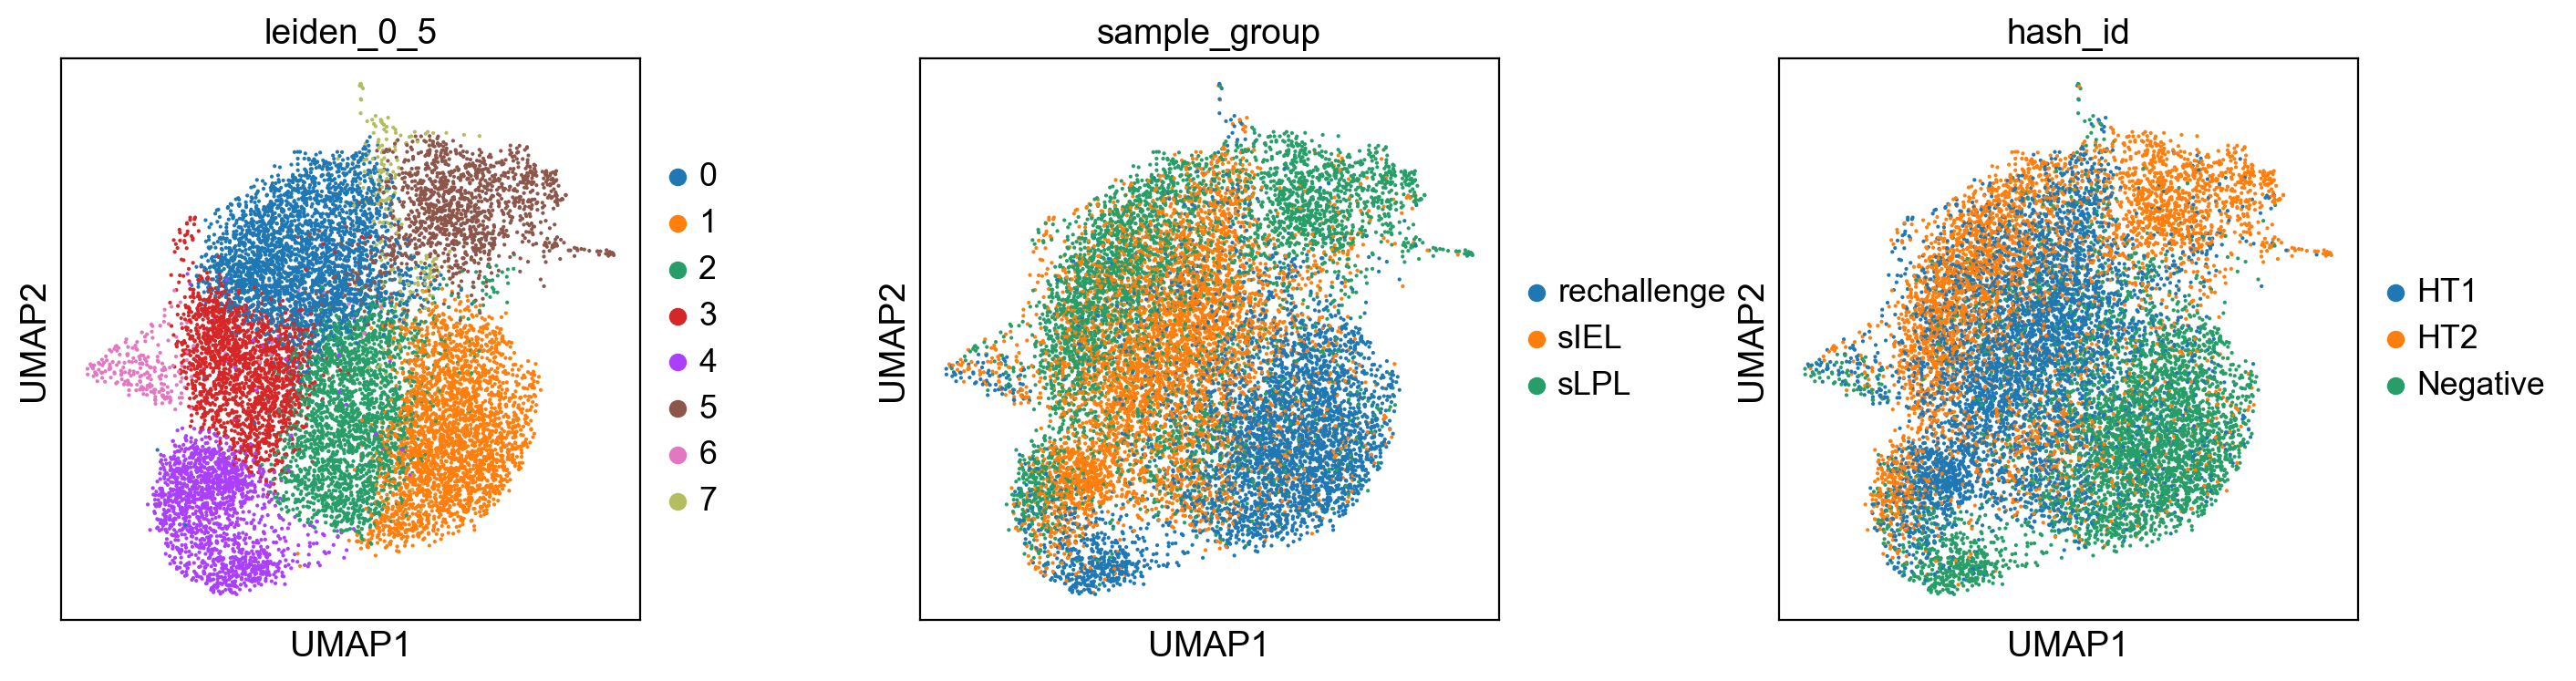

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/03_clustered_umap.h5ad

--- sIEL ---
Loading: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/02_normalized_hvg_pca_sIEL.h5ad
AnnData object with n_obs × n_vars = 5023 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches',

/tmp/ipykernel_3783812/1034498733.py:20: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


    finished: found 7 clusters and added
    'leiden_0_5', the cluster labels (adata.obs, categorical) (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


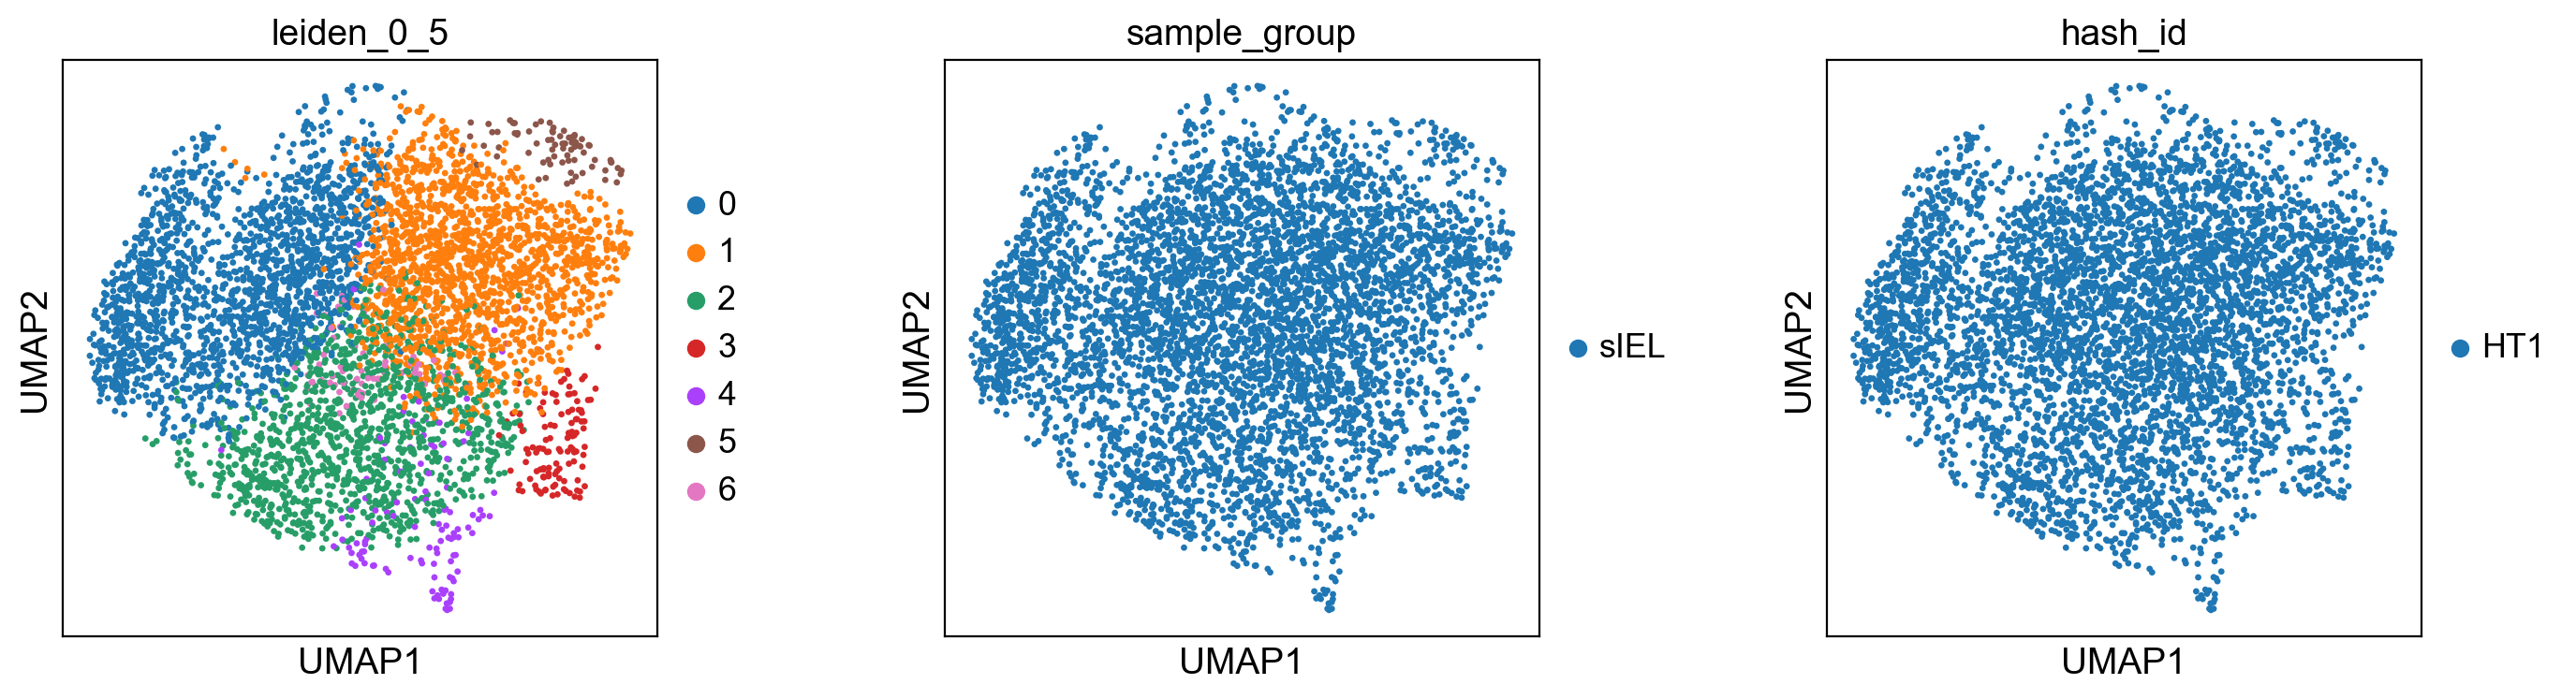

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/03_clustered_umap_sIEL.h5ad

--- sLPL ---
Loading: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/02_normalized_hvg_pca_sLPL.h5ad
AnnData object with n_obs × n_vars = 4249 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatc

/tmp/ipykernel_3783812/1034498733.py:20: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


    finished: found 7 clusters and added
    'leiden_0_5', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


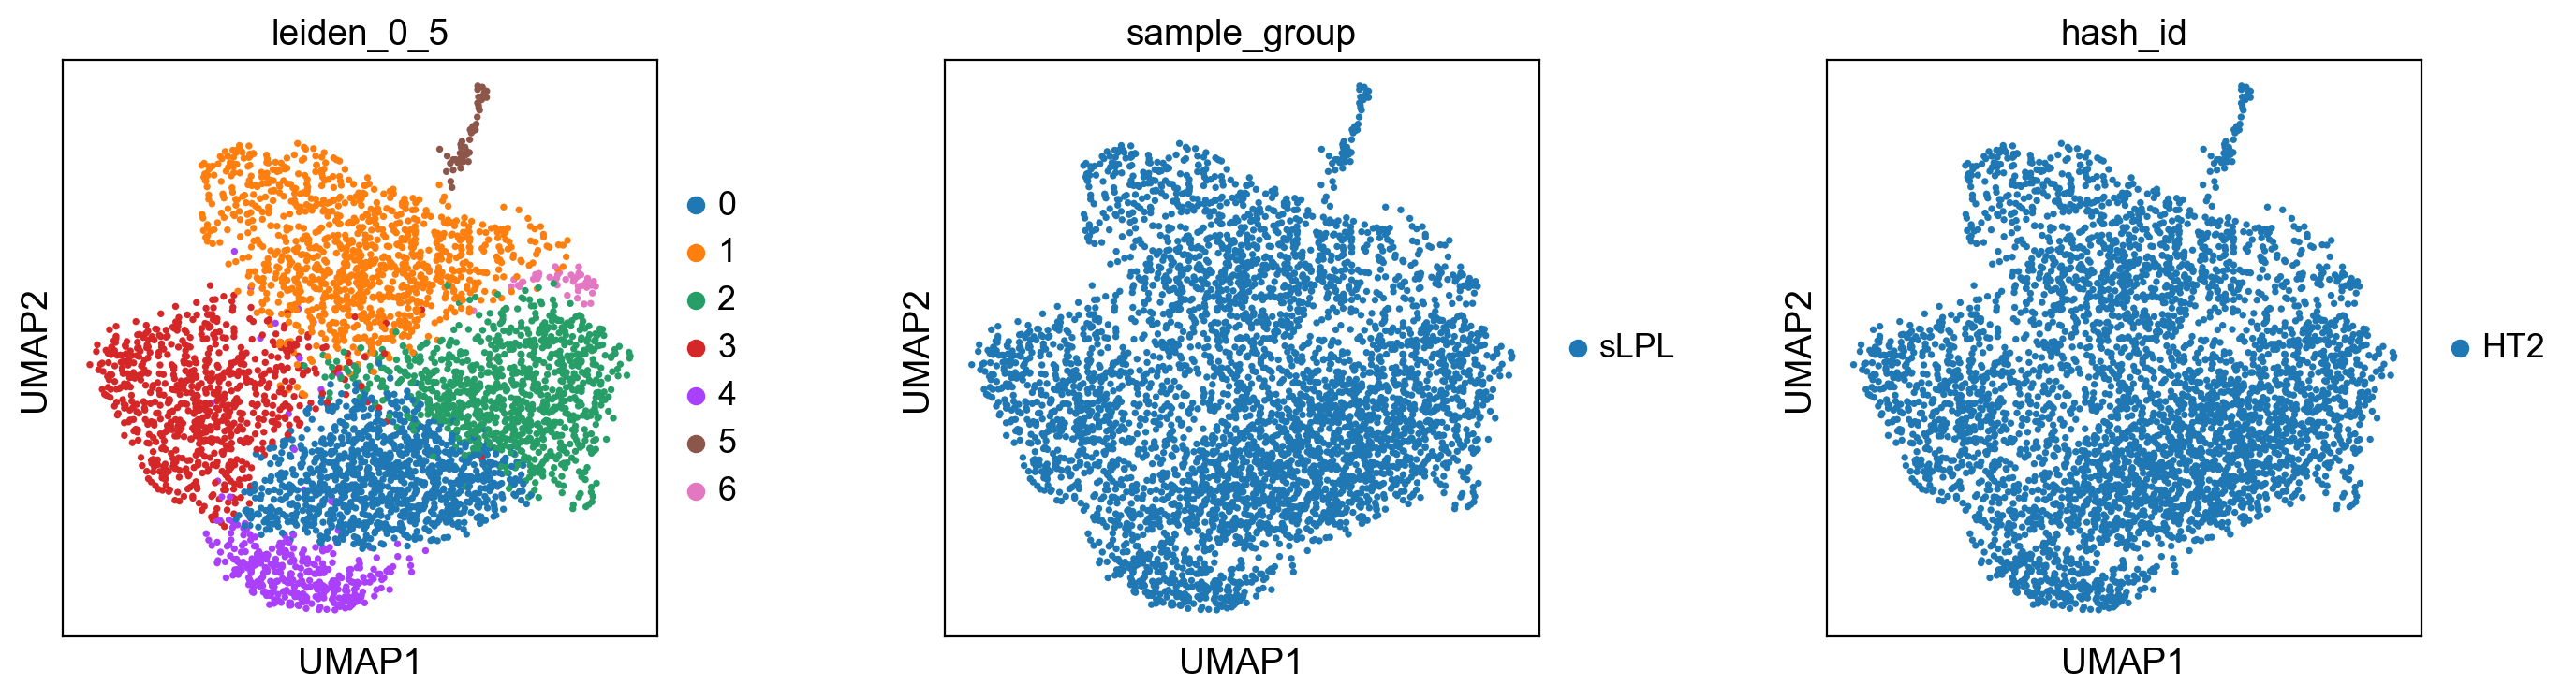

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/03_clustered_umap_sLPL.h5ad

--- rechallenge ---
Loading: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/02_normalized_hvg_pca_rechallenge.h5ad
AnnData object with n_obs × n_vars = 3934 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_

/tmp/ipykernel_3783812/1034498733.py:20: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


    finished: found 6 clusters and added
    'leiden_0_5', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


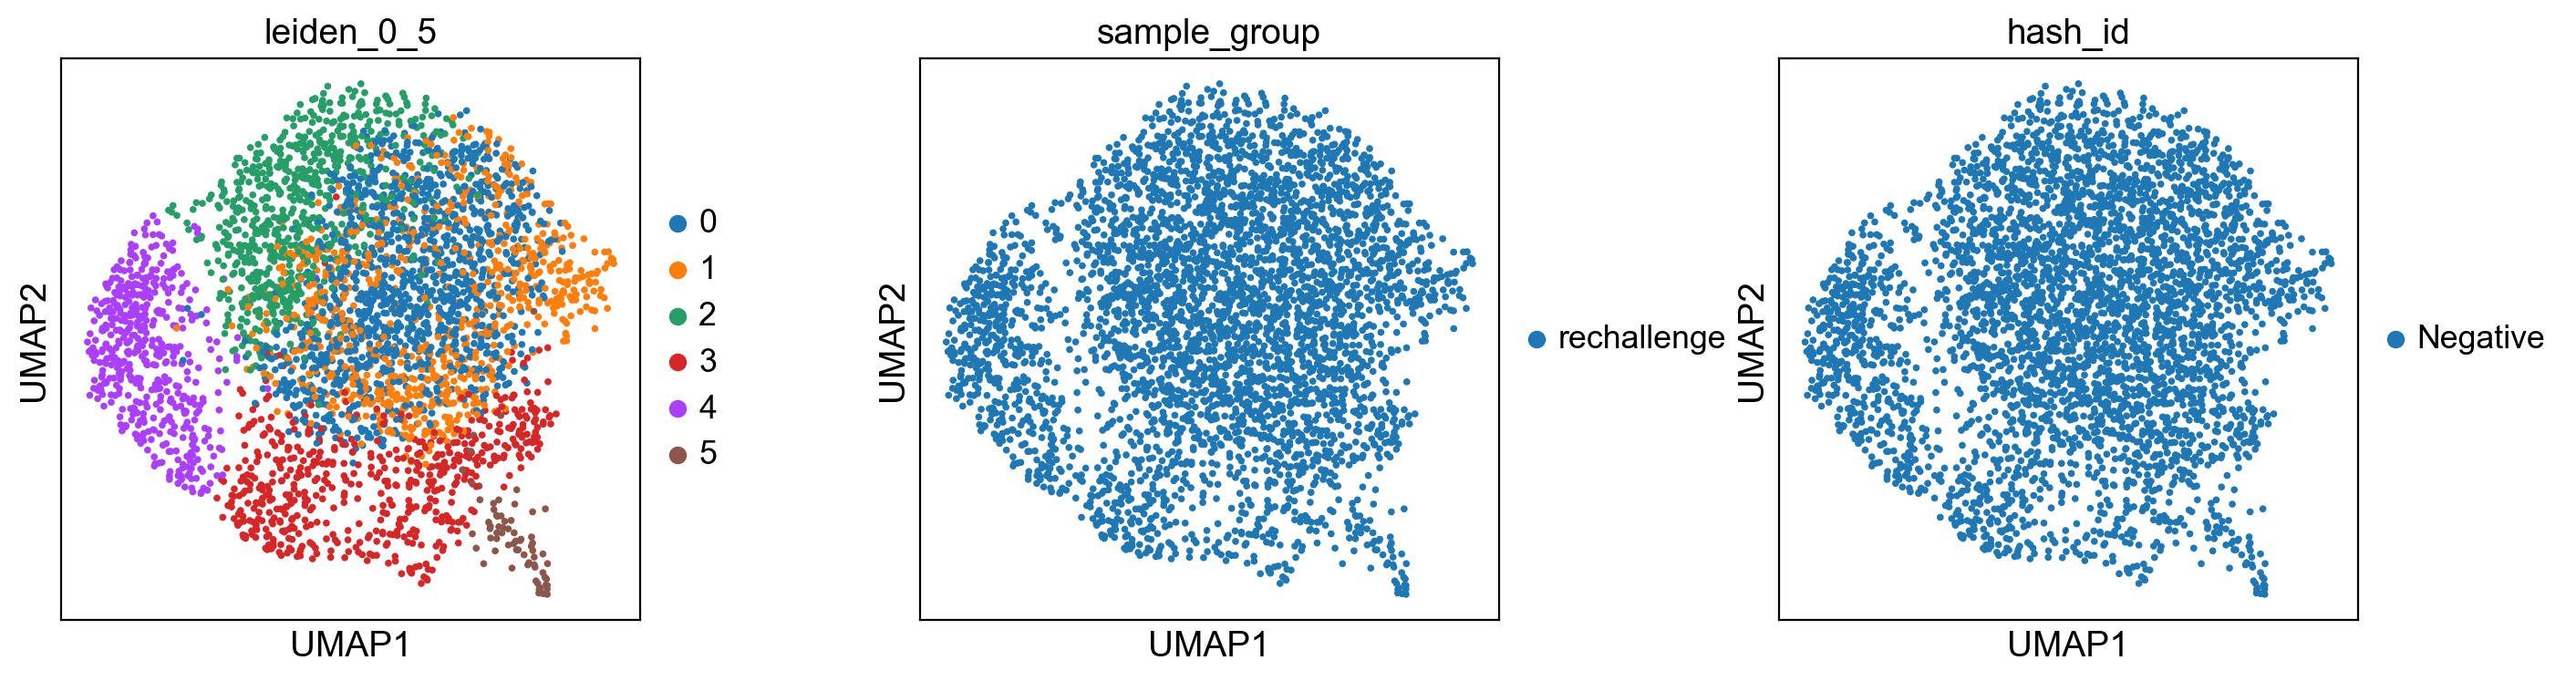

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/03_clustered_umap_rechallenge.h5ad


In [5]:
clustered = {}

for dataset_name, paths in datasets.items():
    clustered[dataset_name] = cluster_and_save(
        dataset_name=dataset_name,
        input_file=paths["input"],
        output_file=paths["output"],
    )


## Cluster Summary

Review cluster sizes before moving on to marker genes or annotation.

In [6]:
cluster_tables = []

for dataset_name, adata in clustered.items():
    table = (
        adata.obs["leiden_0_5"]
        .value_counts()
        .sort_index()
        .rename_axis("leiden_0_5")
        .reset_index(name="n_cells")
    )
    table.insert(0, "dataset", dataset_name)
    cluster_tables.append(table)

cluster_summary = pd.concat(cluster_tables, ignore_index=True)
cluster_summary


,dataset,leiden_0_5,n_cells
0,all,0,2903
1,all,1,2702
2,all,2,2310
3,all,3,1897
4,all,4,1571
5,all,5,1378
6,all,6,233
7,all,7,212
8,sIEL,0,1840
9,sIEL,1,1634


In [7]:
summary_file = RESULTS_DIR / "03_clustered_umap_cluster_summary.csv"
summary_file.parent.mkdir(parents=True, exist_ok=True)
cluster_summary.to_csv(summary_file, index=False)
print("Saved:", summary_file)


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/03_clustered_umap_cluster_summary.csv
